# Clustering Evaluation

In [1]:
import pandas as pd
import json
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans
import numpy as np
import joblib
import matplotlib.pyplot as plt

## Load and Parse Data

In [2]:
def json_to_dict(obj):
    return json.loads(obj)

def load_csv(path):
    df = pd.read_csv(path, dtype={'username':str})
    df['counts'] = df['counts'].map(json_to_dict)
    return df

In [3]:
df = load_csv(r'count_data\all_batches_sub_posts_count.csv')

In [4]:
df.head()

,username,counts
0,---feelingalone---,{'SuicideWatch': 1}
1,-anonymously,{'SuicideWatch': 1}
2,-crave,"{'OopsThatsDeadly': 1, 'tonightsdinner': 2, 'm..."
3,-dogtopus-,"{'NoStupidQuestions': 1, 'TheGirlSurvivalGuide..."
4,-ForPrivacy-,{'SuicideWatch': 1}


## Vectorizing

In [5]:
vec = DictVectorizer(sparse=True)

X_counts = vec.fit_transform(df['counts'].tolist())

X_counts.shape, X_counts.nnz

((218818, 132717), 2674332)

## Normalizing

In [6]:
tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True, sublinear_tf=True)

X_tfidf = tfidf.fit_transform(X_counts)

## Singular Value Decompression

In [7]:
svd = TruncatedSVD(n_components=300, random_state=42)

X_reduced = svd.fit_transform(X_tfidf)

X_reduced.shape

(218818, 300)

## Elbow Method

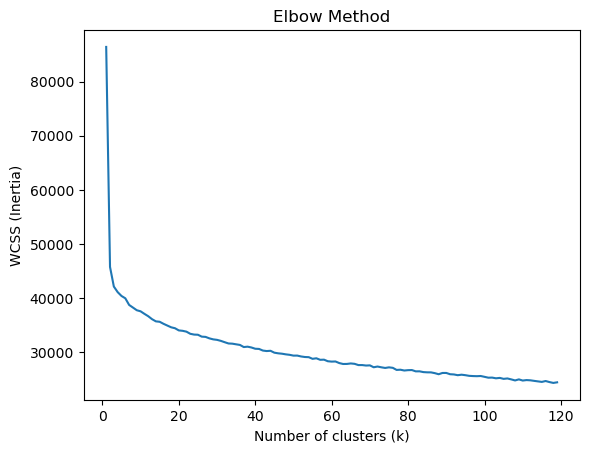

In [9]:
wcss = []
for i in range(1, 120): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_reduced)
    wcss.append(kmeans.inertia_)


plt.plot(range(1, 120), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()

## Clustering

In [21]:
k = 5

kmeans = MiniBatchKMeans(
    n_clusters=k,
    random_state=42,
    batch_size=2000
)

labels=kmeans.fit_predict(X_reduced)
df['clusters'] = labels

c:\Users\vince\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 6144 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


In [22]:
df.head()

,username,counts,clusters
0,---feelingalone---,{'SuicideWatch': 1},2
1,-anonymously,{'SuicideWatch': 1},2
2,-crave,"{'OopsThatsDeadly': 1, 'tonightsdinner': 2, 'm...",0
3,-dogtopus-,"{'NoStupidQuestions': 1, 'TheGirlSurvivalGuide...",3
4,-ForPrivacy-,{'SuicideWatch': 1},2


In [12]:
df.groupby('clusters').size()

clusters
0    104144
1       751
2     66942
3     44760
4      2221
dtype: int64

In [13]:
terms = vec.get_feature_names_out()

def top_subreddits_per_cluster(X_tfidf, labels, top_n=10):
    result = {}
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        mean_vec = X_tfidf[idx].mean(axis=0)       # sparse mean
        top_idx = np.asarray(mean_vec.A1).argsort()[-top_n:][::-1]
        result[c] = [terms[i] for i in top_idx]
    return result

cluster_tops = top_subreddits_per_cluster(X_tfidf, labels, top_n=15)
for c in sorted(cluster_tops):
    print(f"Cluster {c}: {', '.join(cluster_tops[c])}")


Cluster 0: SuicideWatch, AskReddit, aww, funny, tipofmytongue, teenagers, Showerthoughts, memes, NoStupidQuestions, cats, gaming, trees, pics, buildapc, techsupport
Cluster 1: SuicideWatch, depression, AskReddit, selfharm, Advice, Anxiety, relationship_advice, lonely, mentalhealth, aww, raisedbynarcissists, teenagers, Vent, Drugs, asktransgender
Cluster 2: SuicideWatch, zztop, Petscop, PeterboroughUK, PeterboroughUtd, Petercainedestiny, Petgirltraining, Petioles, PetiteAndTiny, PetiteBoobBounce, PetiteFashionAdvice, PetiteFitness, PetiteFitness30plus, PetiteGoneWild, PetiteTits
Cluster 3: SuicideWatch, depression, AskReddit, relationship_advice, selfharm, Advice, relationships, mentalhealth, Anxiety, lonely, offmychest, raisedbynarcissists, BPD, Vent, AmItheAsshole
Cluster 4: offmychest, SuicideWatch, depression, Advice, AskReddit, relationship_advice, confession, TrueOffMyChest, relationships, UnsentLetters, Vent, mentalhealth, AmItheAsshole, raisedbynarcissists, sex


## Saving

In [48]:
df.to_csv(r'count_data\all_batches_sub_posts_count_with_clusters.csv', index=False)

In [50]:
joblib.dump(vec, 'dict_vectorizer.joblib')
joblib.dump(tfidf, 'tfidf.joblib')
joblib.dump(svd, 'svd.joblib')
joblib.dump(kmeans, 'kmeans.joblib')

['kmeans.joblib']

In [ ]:
df = df.groupby('clusters')


In [23]:
grouped = df.groupby('clusters')

In [ ]:
grouped = df.groupby('clusters')

In [26]:
grouped.get_group(0)

,username,counts,clusters
2,-crave,"{'OopsThatsDeadly': 1, 'tonightsdinner': 2, 'm...",0
8,-hhhh-,"{'cringepics': 1, 'SuicideWatch': 1, 'furry': 1}",0
11,-Joker-,"{'Spiderman': 1, 'tf2': 5, 'ShingekiNoKyojin':...",0
13,-No-Way-Out-,"{'MilitaryDocumentaries': 1, 'Military': 1, 'S...",0
14,-Polyphony-,"{'NICUParents': 1, 'Conservative': 1, 'oregon'...",0
...,...,...,...
218810,___TheRed___,"{'SuicideWatch': 1, 'FreeCompliments': 1, 'Jor...",0
218812,______anon_____,"{'sypherpk': 1, 'SuicideWatch': 1, 'mentalheal...",0
218813,brooklynhils,"{'medical_advice': 2, 'DermatologyQuestions': ...",0
218815,iamabovethehill,{},0


In [29]:
grouped.get_group(0)['counts']

2         {'OopsThatsDeadly': 1, 'tonightsdinner': 2, 'm...
8          {'cringepics': 1, 'SuicideWatch': 1, 'furry': 1}
11        {'Spiderman': 1, 'tf2': 5, 'ShingekiNoKyojin':...
13        {'MilitaryDocumentaries': 1, 'Military': 1, 'S...
14        {'NICUParents': 1, 'Conservative': 1, 'oregon'...
                                ...                        
218810    {'SuicideWatch': 1, 'FreeCompliments': 1, 'Jor...
218812    {'sypherpk': 1, 'SuicideWatch': 1, 'mentalheal...
218813    {'medical_advice': 2, 'DermatologyQuestions': ...
218815                                                   {}
218817                                                   {}
Name: counts, Length: 104144, dtype: object

In [ ]:
counts = {}
for i in range(5):
    dict = json.loads(grouped.get_group(i)['counts'])
    # print(dict.keys())
    for key in dict.keys():
        counts[key] = counts.get(key, 0)
        counts[key] = counts[key] + dict[key]
    print(counts)

In [30]:
counts = {}
for i in range(5):
    for row in grouped.get_group(i):
        dict = json.loads(row[1]['counts'])
        # print(dict.keys())
        for key in dict.keys():
            counts[key] = counts.get(key, 0)
            counts[key] = counts[key] + dict[key]
    print(counts)

TypeError: string indices must be integers, not 'str'